In [72]:
#libraries
import h5py
import matplotlib.pyplot as plt
import scienceplots
import numpy as np
import astropy.units as u
import astropy.constants as const
from tqdm import tqdm

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    'font.size': 30,         #tamaño de fuente general
    'axes.titlesize': 30,    #tamaño de fuente para títulos de ejes
    'axes.labelsize': 30,    #tamaño de fuente para etiquetas de ejes
    'xtick.labelsize': 30,   #tamaño de fuente para etiquetas del eje x
    'ytick.labelsize': 30,   #tamaño de fuente para etiquetas del eje y
    'legend.fontsize': 30,   #tamaño de fuente para la leyenda
    'figure.titlesize': 30   #tamaño de fuente para el título de la figura
})

plt.style.use(['science', 'grid'])

In [47]:
#find T_sim and vel_sim
#G = const.G
#print(G)

# Sabemos que: G = 1 * ((u.pc3 /u.Msun)/T_sim2)
# Entonces, despejamos T_sim:

In [48]:
#T_sim = (np.sqrt( 1 * (u.pc**3/u.Msun) * G**(-1)) ).to('Myr')
#print(f'El tiempo de siumación es: {round(T_sim.value, 1)} [Myr]')

In [49]:
#vel_sim = (1/T_sim.value * (u.pc/u.Myr) ).to('m/s')
#print(f'La velocidad de simulación es: {round(vel_sim.value, 1)} [m/s]')

In [73]:
#simulation units
G = 1 #gravity constant
len_sim = 1 #length of simulation in parsec
mass_unit = 1 #mass unit in solar masses
T_sim = 14.9 * np.sqrt((len_sim**3)/mass_unit) #time unit conversion in Myr
vel_sim = 980.4 * (len_sim/T_sim) #velocity unit conversion in m/s
print(f'Simulation Time: {T_sim}. Simulation Velocity: {vel_sim}.')

Simulation Time: 14.9. Simulation Velocity: 65.79865771812081.


In [74]:
#initial conditions
mass = 1*u.Msun #unidades de Msun
x, y, z = 1*u.pc, 0*u.pc, 0*u.pc #unidades de pc
r = np.sqrt(x*x + y*y + z*z) #unidades de pc

v_circ = ( np.sqrt( (const.G* (mass).to('kg') ) / r.to('m') ) ).to('m/s').value #en m/s (unidades físicas)

N_steps = 10**6
t_orbit = (( (2 * np.pi* r.to('m') ) / (v_circ*u.m/u.s) ).to('Myr')).value #adimensional para el ciclo de la simulación, según unidades de simulación
t_end = (10*t_orbit)/ T_sim
t, dt = 0, t_end/N_steps
print(t_end*T_sim)

mass = mass.value/mass_unit #adimensional para el ciclo de la simulación, según unidades de simulación
x, y, z = x.value/len_sim, y.value/len_sim, z.value/len_sim #adimensional para el ciclo de la simulación, según unidades de simulación
r = np.sqrt(x*x + y*y + z*z) #adimensional para el ciclo de la simulación, según unidades de simulación
vx, vy, vz = 0/vel_sim, v_circ/vel_sim, 0/vel_sim #adimensional para el ciclo de la simulación, según unidades de simulación

936.7978861521633


In [75]:
#orbit simulation
x_arr, y_arr, z_arr = np.ones(N_steps, dtype = float), np.ones(N_steps, dtype = float), np.ones(N_steps, dtype = float)
vx_arr, vy_arr, vz_arr = np.ones(N_steps, dtype = float), np.ones(N_steps, dtype = float), np.ones(N_steps, dtype = float)
t_arr = np.ones(N_steps, dtype = float)
r_arr = np.ones(N_steps, dtype = float)

for i in tqdm(range(0, N_steps), 'Procesando: '):
    x_arr[i], y_arr[i], z_arr[i] = x, y, z
    vx_arr[i], vy_arr[i], vz_arr[i] = vx, vy, vz
    t_arr[i] = t 
    t = i*dt
    r = np.sqrt(x*x + y*y + z*z)
    r_arr[i] = r
    ax, ay, az = (-(G*mass)/(r**2))*(x/r), (-(G*mass)/(r**2))*(y/r), (-(G*mass)/(r**2))*(z/r) #G=1
    vx, vy, vz = vx + ax*dt, vy + ay*dt, vz + az*dt
    x, y, z = x + vx*dt, y + vy*dt, z + vz*dt

Procesando: 100%|█████████████████| 1000000/1000000 [00:09<00:00, 105888.35it/s]


In [76]:
x_arr, y_arr, z_arr = x_arr*len_sim, y_arr*len_sim, z_arr*len_sim
r_arr = r_arr * len_sim
vx_arr, vy_arr, vz_arr = vx_arr*vel_sim, vy_arr*vel_sim, vz_arr*vel_sim
t_arr = t_arr * T_sim

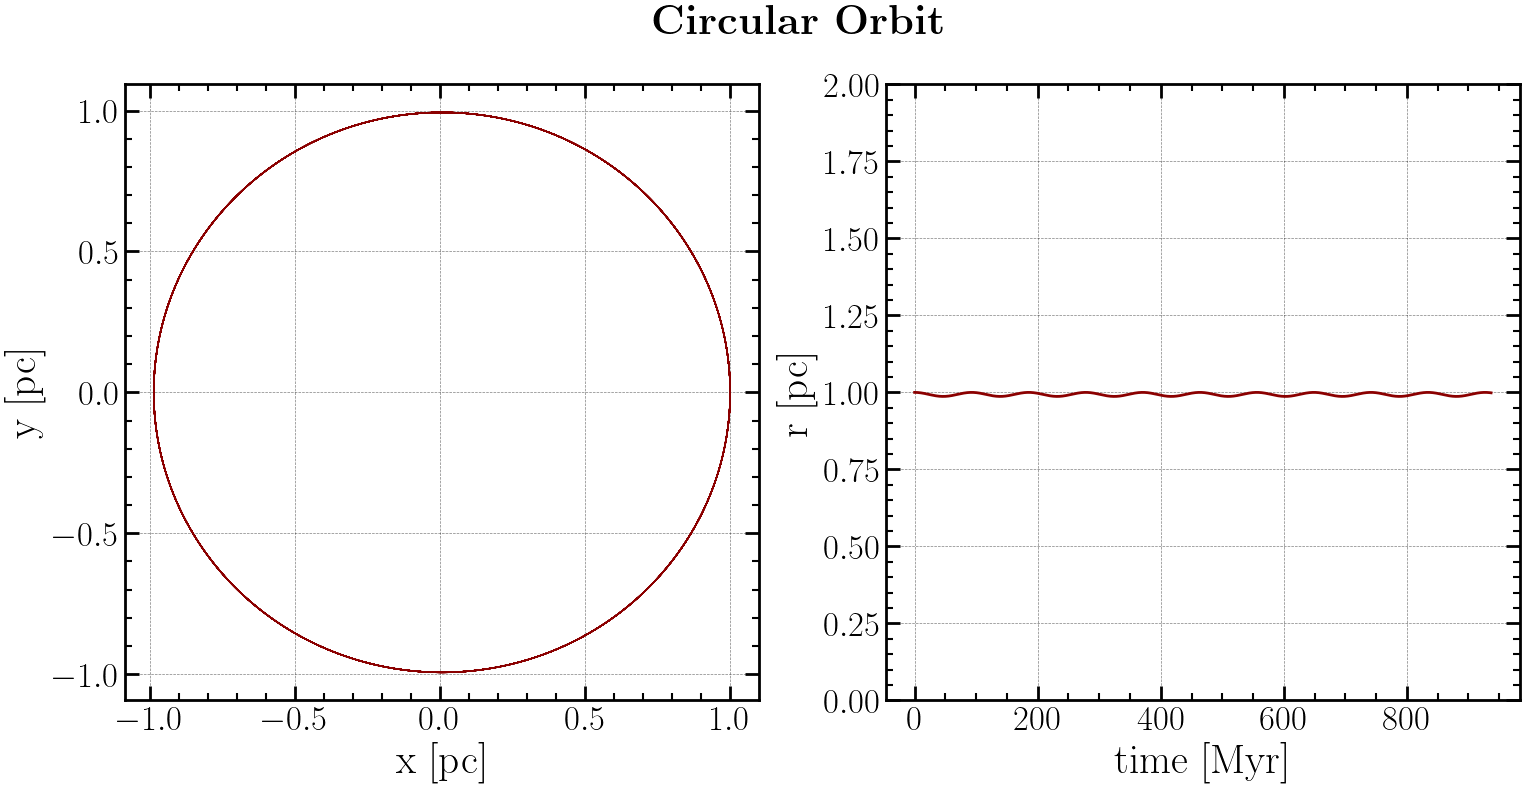

In [85]:
fig = plt.figure(figsize = (18,8))
gs = fig.add_gridspec(1, 2)
ax = gs.subplots(sharex=False, sharey=False)

for i in range(0, 2):
    for spine in ax[i].spines.values():
        spine.set_linewidth(2)
    ax[i].tick_params(axis='both', which='major', labelsize=25, length=10, width=2)
    ax[i].tick_params(axis='both', which='minor', length=5, width=1.5)
    ax[i].minorticks_on()

ax[0].plot(x_arr, y_arr, color = 'darkred')
ax[0].set_xlabel('x [pc]')
ax[0].set_ylabel('y [pc]')

ax[1].plot(t_arr, r_arr, color = 'darkred', lw = 2)
ax[1].set_xlabel('time [Myr]')
ax[1].set_ylabel('r [pc]')
ax[1].set_ylim(0, 2)


fig.suptitle(r'$\textbf{Circular Orbit}$')
plt.show()

El porcentaje de error en el radio es: 1.3 %


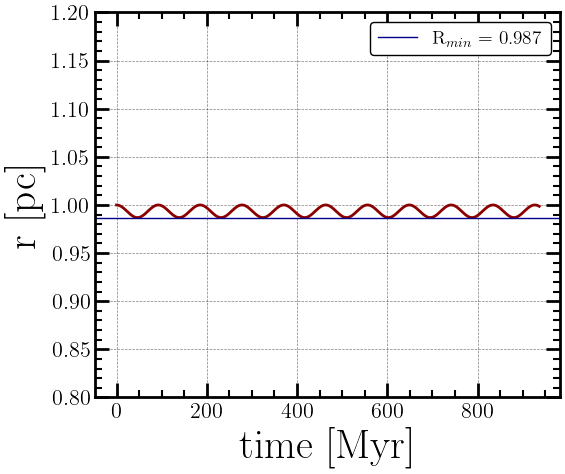

In [103]:
#radius precision
fig = plt.figure(figsize = (6,5))
gs = fig.add_gridspec()
ax = gs.subplots()

for i in range(0, 1):
    for spine in ax.spines.values():
        spine.set_linewidth(2)
    ax.tick_params(axis='both', which='major', labelsize=16, length=10, width=2)
    ax.tick_params(axis='both', which='minor', length=5, width=1.5)
    ax.minorticks_on()
    
ax.plot(t_arr, r_arr, color = 'darkred', lw = 2)
ax.set_xlabel('time [Myr]')
ax.set_ylabel('r [pc]')

max_rad = np.max(r_arr)
min_rad = np.min(r_arr)
error_in_rad = 100 - ((min_rad * 100) / max_rad )
print(f'El porcentaje de error en el radio es: {round(error_in_rad,1)} %')

ax.axhline(min_rad, color = 'darkblue', label = r'R$_{min}$ = '+str(round(min_rad, 3)))
ax.set_ylim(0.8, 1.2)

ax.legend(edgecolor = 'black', frameon = True, fontsize = 14)
plt.show()

In [56]:
from sympy import symbols, diff, pi, log

#Point Mass potential
r, G, M = symbols('r G M')
point_mass_potential = - (G*M) / r 

dfdx_point_mass = diff(point_mass_potential, r)
acel_point_mass = - dfdx_point_mass
print(acel_point_mass)

-G*M/r**2


In [57]:
#NFW potential
r, G, rho, r_s = symbols('r G rho r_s') 
NFW_potential = - ((4*pi*G*rho*(r_s**3))/r)*log(1+(r/r_s))

dfdx_NFW = diff(NFW_potential, r)
acel_NFW = - dfdx_NFW
print(acel_NFW) 

4*pi*G*r_s**2*rho/(r*(r/r_s + 1)) - 4*pi*G*r_s**3*rho*log(r/r_s + 1)/r**2


In [239]:
#Hernquist potential
r, G, M, a = symbols('r G M a')
hern_potential = - (G*M) / (r + a)

dif_hernquist_pot = diff(hern_potential, r)
acel_hernquist = - dif_hernquist_pot
print(acel_hernquist)

-G*M/(a + r)**2


In [244]:
#ejemplo para evaluar valores en las ecuaciones
r, G, M = symbols('r G M')

# Potencial de una masa puntual
point_mass_potential = - (G * M) / r 

# Derivar para obtener la aceleración
dfdx_point_mass = diff(point_mass_potential, r)
acel_point_mass = -dfdx_point_mass

# Sustituir valores numéricos
valores = {G: 6.67430e-11, M: 5.972e24, r: 6.371e6}  # G en m^3/kg/s^2, M en kg, r en m
acel_num = acel_point_mass.subs(valores).evalf()

print(acel_num)  # Debería dar ~9.8 m/s^2 en la Tierra


-9.81997342622469
